In [33]:
import importlib
import numpy as np
import sys
import urllib.request
import matplotlib.pyplot as plt
sys.path.append('../')
import deep_learning.model
#importlib.reload(deep_learning.model)
#importlib.reload(deep_learning.utils)
from deep_learning.utils import train_test_split,plot_learning_curve,plot_neuron_heatmap
from deep_learning.model import Neuron,Sigmoid,BCE #import my implmentation

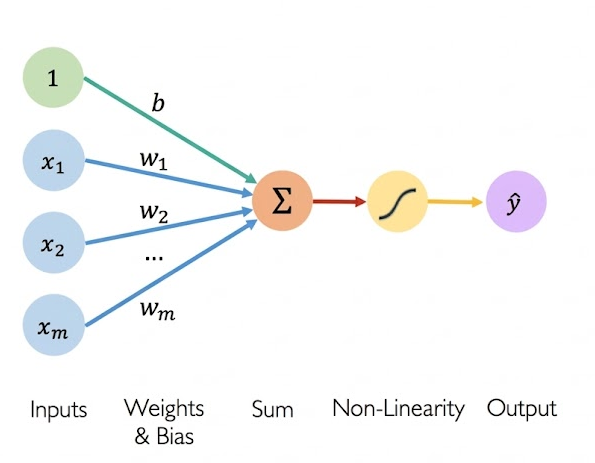

In [35]:
# Iris dataset : The data set contains 3 classes of 50 instances each, where each class refers to a type of iris plant.
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
urllib.request.urlretrieve(url, "iris.csv")  # download


In [36]:
data = np.genfromtxt("iris.csv", delimiter=",", dtype=str)  # read
SETOSA = "Iris-setosa"
VERSICOLOR = "Iris-versicolor"
mask = (data[:, 4] == SETOSA) | (data[:, 4] == VERSICOLOR) # first two classes
data = data[mask]
class_names = np.unique(data[:, 4]) # ['Iris-setosa', 'Iris-versicolor']

In [37]:
X = data[:, 0:4].astype(float)
y = (data[:, 4] == class_names[1]).astype(int)

In [38]:
SEED = 24
(X_train, X_test, y_train, y_test) = train_test_split(X, y, 0.1, SEED)

In [39]:
# normalization by feature
X_min, X_max = X_train.min(axis=0), X_train.max(axis=0) # row colapse
X_train = (X_train - X_min) / (X_max - X_min)
X_test = (X_test - X_min) / (X_max - X_min)

In [42]:
EPOCHS = 2000
LR = 0.1
model = Neuron(X.shape[1], activation_function=Sigmoid(), loss_function=BCE(), lr=LR, seed=SEED)


In [43]:
loss = model.train(X_train, y_train, epochs=EPOCHS,batch_size=8)
for index, epoch_loss in enumerate(loss):
    if index % 10 == 0:
        print(f"Epoch: {index+1} | Loss: {epoch_loss}")

Epoch: 1 | Loss: 7.937149107262529
Epoch: 11 | Loss: 3.7035886550677715
Epoch: 21 | Loss: 2.304885670955823
Epoch: 31 | Loss: 1.6547557367942423
Epoch: 41 | Loss: 1.2871805984414557
Epoch: 51 | Loss: 1.0526871557112223
Epoch: 61 | Loss: 0.8906205197095715
Epoch: 71 | Loss: 0.7720967565541504
Epoch: 81 | Loss: 0.6817115539869838
Epoch: 91 | Loss: 0.6105309106345074
Epoch: 101 | Loss: 0.553028691265153
Epoch: 111 | Loss: 0.5056080119838031
Epoch: 121 | Loss: 0.465829029766698
Epoch: 131 | Loss: 0.43197931349280044
Epoch: 141 | Loss: 0.40282203978712444
Epoch: 151 | Loss: 0.3774418358425536
Epoch: 161 | Loss: 0.3551468425022994
Epoch: 171 | Loss: 0.33540448107946264
Epoch: 181 | Loss: 0.3177981428765516
Epoch: 191 | Loss: 0.30199726855670206
Epoch: 201 | Loss: 0.2877362291945944
Epoch: 211 | Loss: 0.2747991320833661
Epoch: 221 | Loss: 0.2630087002108214
Epoch: 231 | Loss: 0.2522180065337544
Epoch: 241 | Loss: 0.2423042436029788
Epoch: 251 | Loss: 0.23316396715617757
Epoch: 261 | Loss: 0.2

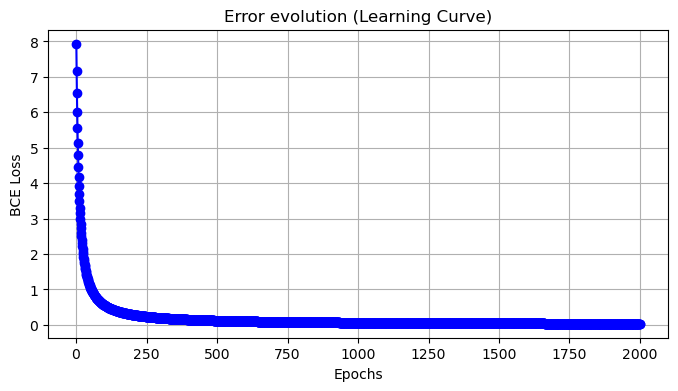

In [44]:
plot_learning_curve(loss, ylabel='BCE Loss')

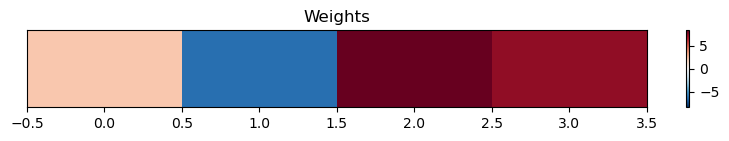

In [45]:
plot_neuron_heatmap(model)

In [46]:
threshold=0.5
probs = model.predict(X_test)                                  
preds = (probs >= threshold).astype(int)                        

for prob, pred, yi in zip(probs, preds, y_test):
    print(f"true: {class_names[int(yi)]}  prediction: {class_names[pred]}  probability: {prob:.3f}")

accuracy = np.mean(preds == y_test)
print(f"Accuracy: {accuracy:.2%}")

true: Iris-setosa  prediction: Iris-setosa  probability: 0.004
true: Iris-versicolor  prediction: Iris-versicolor  probability: 0.999
true: Iris-versicolor  prediction: Iris-versicolor  probability: 0.998
true: Iris-setosa  prediction: Iris-setosa  probability: 0.002
true: Iris-versicolor  prediction: Iris-versicolor  probability: 0.999
true: Iris-versicolor  prediction: Iris-versicolor  probability: 1.000
true: Iris-versicolor  prediction: Iris-versicolor  probability: 0.964
true: Iris-versicolor  prediction: Iris-versicolor  probability: 0.984
true: Iris-setosa  prediction: Iris-setosa  probability: 0.000
true: Iris-setosa  prediction: Iris-setosa  probability: 0.001
Accuracy: 100.00%
